In [1]:
# Instalação das bibliotecas necessárias
# %pip install pandas matplotlib seaborn geobr geopandas shapely

from pyspark import SparkConf
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import DoubleType, IntegerType, StringType, DateType, TimestampType

from pyspark.sql.functions import col, when, regexp_replace, to_date, to_timestamp, date_format, create_map, lit
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from itertools import chain

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURAÇÃO E INICIALIZAÇÃO DO SPARK
# ==========================================
# Define as configurações do Spark, incluindo pacotes para conexão com a AWS S3
conf = SparkConf()
conf.set('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.11.901')
conf.set('spark.hadoop.fs.s3a.aws.credentials.provider', 'com.amazonaws.auth.InstanceProfileCredentialsProvider')
conf.set('spark.sql.legacy.timeParserPolicy', 'LEGACY')

# Cria ou recupera uma sessão ativa do Spark com as configurações definidas acima
spark = SparkSession.builder.config(conf=conf).getOrCreate()

# ==========================================
# LEITURA DOS DADOS (EXTRAÇÃO)
# ==========================================
# Lê o arquivo CSV bruto armazenado no bucket S3
df = spark.read.option('delimiter', ';') \
              .option('header', 'true') \
              .option('nullValue', 'null') \
              .csv('s3a://last-mile-optimization-raw-otavio/arquivo_2015_2016_2017_2018_2019.csv')


:: loading settings :: url = jar:file:/usr/local/lib/python3.7/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-9150a96b-1d27-49d9-928e-ca110fb978df;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 532ms :: artifacts dl 18ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	:: evicted modules:
	com.amazonaws#aws-java-sdk-bundle;1.11.901 by [com.amazonaws#aws-java-sdk-bundle;1.12.262] in [default]
	---------------------------------------------------------------------
	|     

In [2]:
# Importações necessárias para verificação estrutural básica
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, to_date, when
import pyspark.sql.functions as F

# ==========================================
# EXPLORAÇÃO INICIAL DOS DADOS
# ==========================================
# Exibe a estrutura de dados inferida do CSV (nomes das colunas e seus respectivos tipos de dados)
print("=== ESTRUTURA DA TABELA (SCHEMA) ===")
# Conta e imprime a quantidade total de registros no DataFrame
print("Quantidade de linhas: " + str(df.count()))  
df.printSchema()

# Mostra as primeiras 5 linhas completas (sem truncar o conteúdo) para entender visualmente os dados carregados
print("=== AMOSTRA DOS DADOS ===")
print("Quantidade de linhas: " + str(df.count()))
df.show(5, truncate=False)

=== ESTRUTURA DA TABELA (SCHEMA) ===


Quantidade de linhas: 1587576
root
 |-- DATA (YYYY-MM-DD): string (nullable = true)
 |-- HORA (UTC): string (nullable = true)
 |-- PRECIPITAÇÃO TOTAL, HORÁRIO (mm): string (nullable = true)
 |-- PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB): string (nullable = true)
 |-- PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB): string (nullable = true)
 |-- PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB): string (nullable = true)
 |-- RADIACAO GLOBAL (KJ/m²): string (nullable = true)
 |-- TEMPERATURA DO AR - BULBO SECO, HORARIA (°C): string (nullable = true)
 |-- TEMPERATURA DO PONTO DE ORVALHO (°C): string (nullable = true)
 |-- TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C): string (nullable = true)
 |-- TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C): string (nullable = true)
 |-- TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C): string (nullable = true)
 |-- TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C): string (nullable = true)
 |-- UMIDADE REL. MAX. NA HORA ANT. (AUT) (%): string (null

Quantidade de linhas: 1587576
+-----------------+----------+--------------------------------+-----------------------------------------------------+-----------------------------------------------+------------------------------------------------+-----------------------+--------------------------------------------+------------------------------------+------------------------------------------+------------------------------------------+------------------------------------------------+------------------------------------------------+----------------------------------------+----------------------------------------+-----------------------------------+------------------------------------+--------------------------+-------------------------------+-------------------+------------+------------+--------+----+--------+
|DATA (YYYY-MM-DD)|HORA (UTC)|PRECIPITAÇÃO TOTAL, HORÁRIO (mm)|PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)|PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)|PRESSÃO ATMOSFERI

In [3]:
# Importações necessárias
from pyspark.sql.functions import col, when, regexp_replace, to_date, to_timestamp, date_format, create_map, lit, coalesce
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from itertools import chain

# Ajustes de execução para melhorar performance em operações custosas, como joins e agregações (Adaptive Query Execution)
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")

# ==========================================
# 0. CONFIGURAÇÃO DE REFERÊNCIAS
# ==========================================
# Dicionário de mapeamento manual usado para determinar a mesorregião oficial correspondente de cada estação meteorológica do estado de SP
meso_dict = {
    'LINS': 'BAURU', 'CACHOEIRA PAULISTA': 'VALE DO PARAIBA PAULISTA',
    'BRAGANCA PAULISTA': 'MACRO METROPOLITANA PAULISTA', 'SAO LUIZ DO PARAITINGA': 'VALE DO PARAIBA PAULISTA',
    'PRESIDENTE PRUDENTE': 'PRESIDENTE PRUDENTE', 'SAO PAULO - MIRANTE': 'METROPOLITANA DE SAO PAULO',
    'SAO CARLOS': 'ARARAQUARA', 'BERTIOGA': 'METROPOLITANA DE SAO PAULO',
    'REGISTRO': 'LITORAL SUL PAULISTA', 'ITAPEVA': 'ITAPETININGA',
    'BARRA BONITA': 'BAURU', 'JOSE BONIFACIO': 'SAO JOSE DO RIO PRETO',
    'CASA BRANCA': 'CAMPINAS', 'BARUERI': 'METROPOLITANA DE SAO PAULO',
    'IBITINGA': 'ARARAQUARA', 'BARRETOS': 'RIBEIRAO PRETO',
    'ARIRANHA': 'SAO JOSE DO RIO PRETO', 'ITUVERAVA': 'RIBEIRAO PRETO',
    'SAO PAULO - INTERLAGOS': 'METROPOLITANA DE SAO PAULO', 'CAMPOS DO JORDAO': 'VALE DO PARAIBA PAULISTA',
    'FRANCA': 'RIBEIRAO PRETO', 'SAO SIMAO': 'RIBEIRAO PRETO',
    'OURINHOS': 'ASSIS', 'TAUBATE': 'VALE DO PARAIBA PAULISTA',
    'BARRA DO TURVO': 'LITORAL SUL PAULISTA', 'IGUAPE': 'LITORAL SUL PAULISTA',
    'IPERO': 'MACRO METROPOLITANA PAULISTA', 'DRACENA': 'PRESIDENTE PRUDENTE',
    'PRADOPOLIS': 'RIBEIRAO PRETO', 'BAURU': 'BAURU',
    'AVARE': 'BAURU', 'RANCHARIA': 'PRESIDENTE PRUDENTE',
    'VALPARAISO': 'ARACATUBA', 'SAO MIGUEL ARCANJO': 'MACRO METROPOLITANA PAULISTA',
    'MARILIA': 'MARILIA', 'BEBEDOURO': 'RIBEIRAO PRETO',
    'PIRACICABA': 'PIRACICABA', 'ITAPIRA': 'CAMPINAS',
    'JALES': 'SAO JOSE DO RIO PRETO', 'TUPA': 'MARILIA'
}

# Converte o dicionário em uma estrutura Map nativa do Spark, para buscas rápidas (lookups)
mapping_expr = create_map(*[lit(x) for x in chain(*meso_dict.items())])

# Função UDF customizada para limpar e padronizar a formatação numérica do Brasil (vírgula) para padrão americano (ponto) e converter em ponto flutuante (Double)
def decimal_para_double(coluna):
    return regexp_replace(
        regexp_replace(F.trim(col(coluna).cast("string")), "^,", "0,"),
        ",", "."
    ).cast(DoubleType())

# ==========================================
# 1. TRATAMENTO INICIAL EM PASSAGEM ÚNICA
# ==========================================
# Filtra apenas estações presentes no dicionário de interesse, e cria uma base enxuta e convertida
df_foco = (
    df.filter(col("ESTACAO_NOME").isin(list(meso_dict.keys())))
      .select(
          # Formatações de data e separação por hora local - Unindo as colunas dos diferentes anos
          coalesce(
              to_date(col("DATA (YYYY-MM-DD)"), "yyyy-MM-dd"),
              to_date(col("data"), "yyyy/MM/dd")
          ).alias("data"),
          
          # Extraindo a hora, lidando com os diferentes formatos da coluna Hora ("12:00" vs "1200 UTC")
          coalesce(
              date_format(to_timestamp(col("HORA (UTC)"), "HH:mm"), "HH"),
              date_format(to_timestamp(regexp_replace(col("Hora UTC").cast("string"), " UTC", ""), "HHmm"), "HH")
          ).alias("hora"),
          
          col("ESTACAO_NOME").alias("estacao"),
          mapping_expr[col("ESTACAO_NOME")].alias("mesoregiao"),
          # Aplica as conversões com UDFs
          decimal_para_double("latitude").alias("latitude"),
          decimal_para_double("longitude").alias("longitude"),
          decimal_para_double("altitude").alias("altitude"),
          decimal_para_double("`PRECIPITAÇÃO TOTAL, HORÁRIO (mm)`").alias("precipitacao"),
          decimal_para_double("`VENTO, RAJADA MAXIMA (m/s)`").alias("vento_rajada")
      )
)

colunas_limpar = {"precipitacao", "vento_rajada"}
# Converte valores indesejados (-9999 indica sensor quebrado/erro no INMET) para preenchimento Nulo
df_foco = df_foco.select(*[
    when(col(c) == -9999, None).otherwise(col(c)).alias(c) if c in colunas_limpar else col(c)
    for c in df_foco.columns
])

# ==========================================
# 2. AGREGAÇÃO POR PERÍODO
# ==========================================
# Cria categorias dividindo o dia em 4 faixas de tempo baseadas em 6 horas cada, facilitando predição de turnos
df_foco = df_foco.withColumn(
    "intervalo",
    when((col("hora") >= "00") & (col("hora") < "06"), "1 - Madrugada (00h-06h)")
    .when((col("hora") >= "06") & (col("hora") < "12"), "2 - Manhã (06h-12h)")
    .when((col("hora") >= "12") & (col("hora") < "18"), "3 - Tarde (12h-18h)")
    .otherwise("4 - Noite (18h-24h)")
)

# Consolida os registros por intervalo para encontrar o total de chuvas no bloco, pico de chuvas temporal e vento mais forte do bloco
df_periodo = df_foco.groupBy("data", "estacao", "mesoregiao", "intervalo", "latitude", "longitude").agg(
    F.round(F.sum("precipitacao"), 1).alias("chuva_total_periodo"),
    F.round(F.max("precipitacao"), 1).alias("intensidade_max_chuva_mm_h"),
    F.round(F.max("vento_rajada"), 1).alias("vento_rajada_max_periodo")
)

# ==========================================
# TRATAMENTO DE OUTLIERS ANTES DA IMPUTAÇÃO
# ==========================================
# Descarta rajadas de vento impossíveis (<0) ou distorcidas (>60 m/s no BR)
# E descarta registros de chuva que estouram níveis plausíveis (>130mm) com a intenção de considerá-los nulos para sofrerem preenchimento depois
df_periodo = df_periodo.withColumn(
    "vento_rajada_max_periodo",
    when(col("vento_rajada_max_periodo") < 0, None)
    .when(col("vento_rajada_max_periodo") > 60, None)
    .otherwise(col("vento_rajada_max_periodo"))
).withColumn(
    "chuva_total_periodo",
    when(col("chuva_total_periodo") < 0, 0)
    .when(col("intensidade_max_chuva_mm_h") > 130, None)
    .otherwise(col("chuva_total_periodo"))
).withColumn(
    "intensidade_max_chuva_mm_h",
    when(col("intensidade_max_chuva_mm_h") > 130, None)
    .otherwise(col("intensidade_max_chuva_mm_h"))
)

# ==========================================
# 3. MATRIZ DE PROXIMIDADE DAS ESTAÇÕES (TOP 5)
# ==========================================
# Identifica quais devem ser substituídos no futuro
colunas_imputar = ["vento_rajada_max_periodo", "chuva_total_periodo", "intensidade_max_chuva_mm_h"]

# Prepara latitude e longitude de graus para radianos, para uso com fórmula Haversine
df_estacoes = (
    df_periodo.select("estacao", "latitude", "longitude").distinct()
              .withColumn("lat_rad", F.radians(F.col("latitude")))
              .withColumn("lon_rad", F.radians(F.col("longitude")))
)

# Divide a tabela em origem e destino para montar as combinações possíves para cada estação (produto cartesiano/crossJoin)
df_estacoes_a = df_estacoes.select(
    F.col("estacao").alias("estacao_origem"),
    F.col("lat_rad").alias("lat_a"),
    F.col("lon_rad").alias("lon_a")
)
df_estacoes_b = df_estacoes.select(
    F.col("estacao").alias("estacao_destino"),
    F.col("lat_rad").alias("lat_b"),
    F.col("lon_rad").alias("lon_b")
)

# Aplica o cálculo matemático (Fórmula de Haversine) para achar a distância (em km) real da curvatura do planeta entre Estação A e B.
df_dist = (
    df_estacoes_a.crossJoin(df_estacoes_b)
                .filter(F.col("estacao_origem") != F.col("estacao_destino"))
                .withColumn("dlat_2", (F.col("lat_b") - F.col("lat_a")) / 2)
                .withColumn("dlon_2", (F.col("lon_b") - F.col("lon_a")) / 2)
                .withColumn("a", F.sin(F.col("dlat_2"))**2 + F.cos(F.col("lat_a")) * F.cos(F.col("lat_b")) * F.sin(F.col("dlon_2"))**2)
                .withColumn("distancia_km", 2 * 6371 * F.asin(F.sqrt(F.col("a"))))
)

# Ranqueia a distância de cada estação e salva nas Top 5 mais próximas
window_vizinhos = Window.partitionBy("estacao_origem").orderBy("distancia_km")
df_vizinhos = (
    df_dist.withColumn("rank", F.row_number().over(window_vizinhos))
           .filter(F.col("rank") <= 5)
           .select("estacao_origem", "estacao_destino", "rank")
)

print("Pré-processamento e matriz de proximidade concluídos.")

Pré-processamento e matriz de proximidade concluídos.


In [4]:
# ==========================================
# 4. IMPUTAÇÃO + FALLBACKS
# ==========================================
# Diagnóstico de campos inconsistentes listando colunas e contando Nulos antes das etapas seguintes de imputação
print("\n[MÉTRICA] Contagem de Valores Nulos ANTES da Imputação:")
exprs_nulos_antes = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df_periodo.columns]
df_periodo.agg(*exprs_nulos_antes).show(truncate=False)

# 4.1 Imputação por vizinhos (fluxo único de join)
# Define ID sequêncial base para não se perder mapeando linhas do dataframe
df_base = df_periodo.withColumn("row_id", F.monotonically_increasing_id()).cache()

# Consulta as métricas reais em base (LookUp) necessárias para injetar as combinações climáticas do dia da estação destino para a de origem.
df_lookup = df_base.select(
    F.col("data").alias("data_ref"),
    F.col("intervalo").alias("intervalo_ref"),
    F.col("estacao").alias("estacao_ref"),
    *[F.col(c).alias(f"{c}_ref") for c in colunas_imputar]
)

# Cruzamento dos valores entre Estação a sofrer imputação VS valores conténdo o TOP 5 vizinhos via BROADCAST JOIN (rápida alocação otimizada) 
df_candidatos = (
    df_base.select("row_id", "data", "intervalo", "estacao")
           .join(F.broadcast(df_vizinhos), F.col("estacao") == F.col("estacao_origem"), "left")
           .join(
               df_lookup,
               (F.col("data") == F.col("data_ref")) &
               (F.col("intervalo") == F.col("intervalo_ref")) &
               (F.col("estacao_destino") == F.col("estacao_ref")),
               "left"
           )
)

# Extração dos medidores da estação vizinha válida que está mais próxima possível da estação focada cujo valor não estava ausente
# Utilizamos arrays da linguagem M (SQL array_sort -> collect_list) e capturamos o de melhor ranking no final (try_element_at evita erro quando não há nenhum vizinho válido)
exprs_vizinhos = [
    F.expr(
        f"""
        try_element_at(
          transform(
            filter(
              array_sort(collect_list(named_struct('r', rank, 'v', `{c}_ref`))),
              x -> x.v is not null
            ),
            x -> x.v
          ),
          1
        )
        """
    ).alias(f"{c}_viz")
    for c in colunas_imputar
]

# Agregando os valores recuperados aos IDs da tabela originais base
df_fill_vizinhos = df_candidatos.groupBy("row_id").agg(*exprs_vizinhos)

# Usando coalescência (coalesce) tentamos primeiramente o nosso próprio valor da base, senão usamos o preenchido de vizinhos extraido das rotinas acima  
df_periodo = df_base.join(df_fill_vizinhos, on="row_id", how="left")
for c in colunas_imputar:
    df_periodo = df_periodo.withColumn(c, F.coalesce(F.col(c), F.col(f"{c}_viz")))

# Remove as colunas de ID já mapeadas, aliviando carregamento cache na RAM
df_periodo = df_periodo.drop("row_id", *[f"{c}_viz" for c in colunas_imputar])
df_base.unpersist()

# 4.2 Fallback regional
# Caso em último caso os dados continuem sem estarem preenchidos devido aos 5 vizinhos também não terem tido reportes na data, obtemos por Região
df_media_meso = df_periodo.groupBy("data", "intervalo", "mesoregiao").agg(
    F.round(F.mean("vento_rajada_max_periodo"), 2).alias("vento_rajada_meso"),
    F.round(F.mean("chuva_total_periodo"), 2).alias("chuva_meso"),
    F.round(F.mean("intensidade_max_chuva_mm_h"), 2).alias("intensidade_meso")
)

df_periodo = df_periodo.join(df_media_meso, on=["data", "intervalo", "mesoregiao"], how="left")

mapa_cols_meso = {
    "vento_rajada_max_periodo": "vento_rajada_meso",
    "chuva_total_periodo": "chuva_meso",
    "intensidade_max_chuva_mm_h": "intensidade_meso"
}

# Faz uma segunda coalescência (preenchimento usando lógica Fallback de base territorial para Mesoregião)
for c in colunas_imputar:
    df_periodo = df_periodo.withColumn(c, F.coalesce(F.col(c), F.col(mapa_cols_meso[c])))

df_periodo = df_periodo.drop(*mapa_cols_meso.values())

# 4.3 Fallback final
# O último dos fallbacks - caso em absoluto não se tenha média da mesoresão, utilizo as médias agregadas absolutas/Globais colhidas de todo os anos
medias_globais = df_periodo.agg(
    F.mean("vento_rajada_max_periodo").alias("vento_media"),
    F.mean("latitude").alias("lat_media"),
    F.mean("longitude").alias("lon_media")
).collect()[0]

def v_ou_padrao(v, padrao):
    return float(v) if v is not None else float(padrao)

# Atribuições fixas se necessário fallback de latitude e preenchendo as colunas restantes com zeros nos temporais absolutos
fill_final = {
    "chuva_total_periodo": 0.0,
    "intensidade_max_chuva_mm_h": 0.0,
    "vento_rajada_max_periodo": v_ou_padrao(medias_globais["vento_media"], 0.0),
    "latitude": v_ou_padrao(medias_globais["lat_media"], -22.9),
    "longitude": v_ou_padrao(medias_globais["lon_media"], -47.06),
    "mesoregiao": "Desconhecida",
    "intervalo": "Indefinido"
}

df_periodo = df_periodo.fillna(fill_final)

# 4.4 Normalização geográfica por estação
# Garante que cada estação fique associada a um único par latitude/longitude,
# escolhendo a combinação mais frequente observada na base tratada.
df_geo_canonico = (
    df_periodo.groupBy("estacao", "latitude", "longitude")
    .agg(F.count("*").alias("freq"))
)

window_geo = Window.partitionBy("estacao").orderBy(F.col("freq").desc(), F.col("latitude").asc(), F.col("longitude").asc())
df_geo_canonico = (
    df_geo_canonico.withColumn("geo_rank", F.row_number().over(window_geo))
    .filter(F.col("geo_rank") == 1)
    .select("estacao", F.col("latitude").alias("latitude_canonica"), F.col("longitude").alias("longitude_canonica"))
)

df_periodo = (
    df_periodo.drop("latitude", "longitude")
    .join(df_geo_canonico, on="estacao", how="left")
    .withColumnRenamed("latitude_canonica", "latitude")
    .withColumnRenamed("longitude_canonica", "longitude")
)

# Remoção defensiva de registros vitais ausentes sem chave primária para junção de negócio 
df_periodo = df_periodo.filter(F.col("data").isNotNull() & F.col("estacao").isNotNull())

# Garantir o arredondamento final de precisão métricas (1 casa decimal)
cols_arredondar = {"intensidade_max_chuva_mm_h", "vento_rajada_max_periodo", "chuva_total_periodo"}
df_periodo = df_periodo.select(
    *[F.round(F.col(c), 1).alias(c) if c in cols_arredondar else F.col(c) for c in df_periodo.columns]
)

# ==========================================
# 5. ENGENHARIA DE ATRIBUTOS E VALIDAÇÃO
# ==========================================
# Engenhariade Feature - Classificando tempestades em categorias compreensíveis qualitativas mediante acamulo por milímetros por hora
df_periodo = df_periodo.withColumn(
    "classificacao_chuva",
    when(col("intensidade_max_chuva_mm_h") == 0, "Sem Chuva")
    .when(col("intensidade_max_chuva_mm_h") < 2.5, "Chuva fraca")
    .when((col("intensidade_max_chuva_mm_h") >= 2.5) & (col("intensidade_max_chuva_mm_h") < 10), "Chuva moderada")
    .when((col("intensidade_max_chuva_mm_h") >= 10) & (col("intensidade_max_chuva_mm_h") <= 50), "Chuva forte")
    .otherwise("Chuva violenta")
)

# Engenhariade Feature - Escala oficial padronizada qualitativa Beaufort p/ vento para classificar riscos logísticos
df_periodo = df_periodo.withColumn(
    "classificacao_vento",
    when(col("vento_rajada_max_periodo") < 0.5, "Calmo")
    .when(col("vento_rajada_max_periodo") < 1.6, "Aragem")
    .when(col("vento_rajada_max_periodo") < 3.4, "Brisa leve")
    .when(col("vento_rajada_max_periodo") < 5.5, "Brisa fraca")
    .when(col("vento_rajada_max_periodo") < 8.0, "Brisa moderada")
    .when(col("vento_rajada_max_periodo") < 10.8, "Brisa forte")
    .when(col("vento_rajada_max_periodo") < 13.9, "Vento fresco")
    .when(col("vento_rajada_max_periodo") < 17.2, "Vento forte")
    .when(col("vento_rajada_max_periodo") < 20.8, "Ventania")
    .when(col("vento_rajada_max_periodo") < 24.5, "Ventania forte")
    .when(col("vento_rajada_max_periodo") < 28.5, "Tempestade")
    .when(col("vento_rajada_max_periodo") < 32.7, "Tempestade violenta")
    .otherwise("Furacão")
)

# Ordenação cronológica e locacional 
df_periodo = df_periodo.orderBy("data", "estacao", "intervalo")

# Checagem final de integridade (Verificação contendo métricas analíticas extraidas demonstrando fim dos Nulos)
print("\n=== VERIFICAÇÃO FINAL APÓS PROCESSAMENTO ===")
print(f"Total de Registros Processados: {df_periodo.count()}")

print("\n[MÉTRICA] Contagem de Valores Nulos nas Colunas Finais:")
exprs_nulos = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df_periodo.columns]
df_nulos = df_periodo.agg(*exprs_nulos)
df_nulos.show(truncate=False)

print("\n[MÉTRICA] Distribuição das Categorias de Chuva:")
df_periodo.groupBy("classificacao_chuva").count().orderBy("count", ascending=False).show()

print("\n[MÉTRICA] Distribuição das Categorias de Vento (Beaufort):")
df_periodo.groupBy("classificacao_vento").count().orderBy("count", ascending=False).show()

print(df_periodo.show(30, truncate=False))


[MÉTRICA] Contagem de Valores Nulos ANTES da Imputação:


+----+-------+----------+---------+--------+---------+-------------------+--------------------------+------------------------+
|data|estacao|mesoregiao|intervalo|latitude|longitude|chuva_total_periodo|intensidade_max_chuva_mm_h|vento_rajada_max_periodo|
+----+-------+----------+---------+--------+---------+-------------------+--------------------------+------------------------+
|0   |0      |0         |0        |0       |0        |18830              |18830                     |20477                   |
+----+-------+----------+---------+--------+---------+-------------------+--------------------------+------------------------+




=== VERIFICAÇÃO FINAL APÓS PROCESSAMENTO ===


Total de Registros Processados: 234848

[MÉTRICA] Contagem de Valores Nulos nas Colunas Finais:


+-------+----+---------+----------+-------------------+--------------------------+------------------------+--------+---------+-------------------+-------------------+
|estacao|data|intervalo|mesoregiao|chuva_total_periodo|intensidade_max_chuva_mm_h|vento_rajada_max_periodo|latitude|longitude|classificacao_chuva|classificacao_vento|
+-------+----+---------+----------+-------------------+--------------------------+------------------------+--------+---------+-------------------+-------------------+
|0      |0   |0        |0         |0                  |0                         |0                       |0       |0        |0                  |0                  |
+-------+----+---------+----------+-------------------+--------------------------+------------------------+--------+---------+-------------------+-------------------+


[MÉTRICA] Distribuição das Categorias de Chuva:


+-------------------+------+
|classificacao_chuva| count|
+-------------------+------+
|          Sem Chuva|188102|
|        Chuva fraca| 32647|
|     Chuva moderada| 10112|
|        Chuva forte|  3944|
|     Chuva violenta|    43|
+-------------------+------+


[MÉTRICA] Distribuição das Categorias de Vento (Beaufort):


+-------------------+-----+
|classificacao_vento|count|
+-------------------+-----+
|     Brisa moderada|77373|
|        Brisa fraca|58817|
|        Brisa forte|44612|
|         Brisa leve|30054|
|       Vento fresco|12528|
|              Calmo| 5245|
|             Aragem| 2784|
|        Vento forte| 2533|
|           Ventania|  683|
|     Ventania forte|  199|
|         Tempestade|   18|
|Tempestade violenta|    2|
+-------------------+-----+



+----------------+----------+-----------------------+--------------------------+-------------------+--------------------------+------------------------+------------+------------+-------------------+-------------------+
|estacao         |data      |intervalo              |mesoregiao                |chuva_total_periodo|intensidade_max_chuva_mm_h|vento_rajada_max_periodo|latitude    |longitude   |classificacao_chuva|classificacao_vento|
+----------------+----------+-----------------------+--------------------------+-------------------+--------------------------+------------------------+------------+------------+-------------------+-------------------+
|ARIRANHA        |2015-01-01|1 - Madrugada (00h-06h)|SAO JOSE DO RIO PRETO     |0.0                |0.0                       |1.5                     |-21.13305554|-48.84027777|Sem Chuva          |Aragem             |
|ARIRANHA        |2015-01-01|2 - Manhã (06h-12h)    |SAO JOSE DO RIO PRETO     |0.0                |0.0                     

In [5]:
# ==========================================
# 6. FORMATAÇÃO FINAL E EXPORTAÇÃO
# ==========================================
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from pyspark.sql.functions import col
from itertools import chain

# Mapeamento de intervalo (comentado para referência):
# 1 -> Madrugada (00h-06h)
# 2 -> Manhã (06h-12h)
# 3 -> Tarde (12h-18h)
# 4 -> Noite (18h-24h)
interval_code_map = {
    "1 - Madrugada (00h-06h)": 1,
    "2 - Manhã (06h-12h)": 2,
    "3 - Tarde (12h-18h)": 3,
    "4 - Noite (18h-24h)": 4,
    "Indefinido": 0
}

# Mapeamento de classificação da chuva (comentado para referência):
# 0 -> Sem Chuva
# 1 -> Chuva fraca
# 2 -> Chuva moderada
# 3 -> Chuva forte
# 4 -> Chuva violenta
rain_class_code_map = {
    "Sem Chuva": 0,
    "Chuva fraca": 1,
    "Chuva moderada": 2,
    "Chuva forte": 3,
    "Chuva violenta": 4,
    "Indefinido": -1
}

# Mapeamento de classificação do vento (comentado para referência):
# Classificação dos ventos baseada na Escala Beaufort (Convertida para m/s)
# 0: < 0.5 m/s         -> Calmo
# 1: 0.5 a 1.5 m/s     -> Aragem
# 2: 1.6 a 3.3 m/s     -> Brisa leve
# 3: 3.4 a 5.4 m/s     -> Brisa fraca
# 4: 5.5 a 7.9 m/s     -> Brisa moderada
# 5: 8.0 a 10.7 m/s    -> Brisa forte
# 6: 10.8 a 13.8 m/s   -> Vento fresco
# 7: 13.9 a 17.1 m/s   -> Vento forte
# 8: 17.2 a 20.7 m/s   -> Ventania
# 9: 20.8 a 24.4 m/s   -> Ventania forte
# 10: 24.5 a 28.4 m/s  -> Tempestade
# 11: 28.5 a 32.6 m/s  -> Tempestade violenta
# 12: >= 32.7 m/s      -> Furacão
wind_class_code_map = {
    "Calmo": 0,
    "Aragem": 1,
    "Brisa leve": 2,
    "Brisa fraca": 3,
    "Brisa moderada": 4,
    "Brisa forte": 5,
    "Vento fresco": 6,
    "Vento forte": 7,
    "Ventania": 8,
    "Ventania forte": 9,
    "Tempestade": 10,
    "Tempestade violenta": 11,
    "Furacão": 12,
    "Indefinido": -1
}

# Usamos itertools Chain p/ criar map nativo via expr Spark dos dicionários
interval_expr = F.create_map(*[F.lit(x) for x in chain(*interval_code_map.items())])
rain_class_expr = F.create_map(*[F.lit(x) for x in chain(*rain_class_code_map.items())])
wind_class_expr = F.create_map(*[F.lit(x) for x in chain(*wind_class_code_map.items())])

# Definição de janela para o cálculo de enchente (Rolling Window de 3 períodos)
window_3_days = Window.partitionBy("estacao").orderBy("data").rowsBetween(-3, 0)

# Geração de colunas padronizadas finais do modelo limpo e internacionalizado - Inglês foi adotado como default p/ ML
df_periodo_en = (
    df_periodo
    .withColumn("interval_code", interval_expr[col("intervalo")])
    .withColumn("rain_class_code", rain_class_expr[col("classificacao_chuva")])
    .withColumn("wind_class_code", wind_class_expr[col("classificacao_vento")])
    
    # Casting explícito preenchendo Indefinidos resultantes c/ literais base
    .withColumn("interval_code", F.coalesce(col("interval_code"), F.lit(0)).cast("int"))
    .withColumn("rain_class_code", F.coalesce(col("rain_class_code"), F.lit(-1)).cast("int"))
    .withColumn("wind_class_code", F.coalesce(col("wind_class_code"), F.lit(-1)).cast("int"))
    
    # NOVAS REGRAS DE FEATURE ENGINEERING:
    # 2. SAZONALIDADE (MÊS)
    .withColumn("month", F.month("data"))
    
    # 4. EFEITO DE ENCHENTE (Rolling Window)
    .withColumn("chuva_acumulada_3_dias_mm", F.sum("chuva_total_periodo").over(window_3_days))
    
    # 3. FLAGS DE EVENTOS EXTREMOS (Binários)
    .withColumn("is_heavy_rain", F.when(col("intensidade_max_chuva_mm_h") >= 10.0, 1).otherwise(0))
    .withColumn("is_strong_wind", F.when(col("vento_rajada_max_periodo") >= 13.9, 1).otherwise(0))
    
    # 1. NÃO DESCARTE A GEOGRAFIA: removida a 'mesoregiao' da lista de exclusão do drop
    # Remoção das colunas sujas, textuais longas e categorias agora já transformadas com base em Inteiros
    .drop("intervalo", "classificacao_chuva", "classificacao_vento", "estacao")  
    
    # Alteração semântica para o Padrão Final das colunas em inglês p/ integração de base Global
    .withColumnRenamed("data", "date")
    .withColumnRenamed("chuva_total_periodo", "total_rainfall_period_mm")
    .withColumnRenamed("intensidade_max_chuva_mm_h", "max_rain_intensity_mm_h")
    .withColumnRenamed("vento_rajada_max_periodo", "max_wind_gust_period_ms")
    .withColumnRenamed("chuva_acumulada_3_dias_mm", "accumulated_rainfall_3_days_mm")
    .withColumnRenamed("mesoregiao", "region")
)

# Garantia de apenas 1 ponto flutuante via arredondamento
float_cols = [
    "total_rainfall_period_mm",
    "max_rain_intensity_mm_h",
    "max_wind_gust_period_ms",
    "accumulated_rainfall_3_days_mm"
]
for c in float_cols:
    df_periodo_en = df_periodo_en.withColumn(c, F.round(col(c), 1))

# Amostragem da etapa de Tradução / Finalização para atestar a qualidade visual do output
print("Tabela formatada criada: df_periodo_en")
print("Colunas finais:")
df_periodo_en.select(
    "date", "month", "region", "latitude", "longitude", "interval_code", "rain_class_code",
    "total_rainfall_period_mm", "accumulated_rainfall_3_days_mm",
    "max_rain_intensity_mm_h", "is_heavy_rain", "max_wind_gust_period_ms", "wind_class_code", "is_strong_wind"
).show(10, truncate=False)

# ==========================================
# RESUMO GERAL ESTATÍSTICO ANTES DA EXPORTAÇÃO
# ==========================================
print("\n=== RESUMO GERAL DOS DADOS (DESCRIBE) ===")
print(f"Total de registros na base final: {df_periodo_en.count()}")

print("\n[SCHEMA DA BASE FINAL]")
df_periodo_en.printSchema()

print("\n[ESTATÍSTICAS DESCRITIVAS DAS MÉTRICAS CLIMÁTICAS]")
df_periodo_en.select(
    "total_rainfall_period_mm", 
    "accumulated_rainfall_3_days_mm",
    "max_rain_intensity_mm_h", 
    "max_wind_gust_period_ms"
).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

Tabela formatada criada: df_periodo_en
Colunas finais:


+----------+-----+--------------------+------------+------------+-------------+---------------+------------------------+------------------------------+-----------------------+-------------+-----------------------+---------------+--------------+
|date      |month|region              |latitude    |longitude   |interval_code|rain_class_code|total_rainfall_period_mm|accumulated_rainfall_3_days_mm|max_rain_intensity_mm_h|is_heavy_rain|max_wind_gust_period_ms|wind_class_code|is_strong_wind|
+----------+-----+--------------------+------------+------------+-------------+---------------+------------------------+------------------------------+-----------------------+-------------+-----------------------+---------------+--------------+
|2015-01-01|1    |LITORAL SUL PAULISTA|-24.96305555|-48.41638888|1            |0              |0.0                     |0.0                           |0.0                    |0            |3.0                    |2              |0             |
|2015-01-01|1    |LI

Total de registros na base final: 234848

[SCHEMA DA BASE FINAL]
root
 |-- date: date (nullable = true)
 |-- region: string (nullable = false)
 |-- total_rainfall_period_mm: double (nullable = true)
 |-- max_rain_intensity_mm_h: double (nullable = true)
 |-- max_wind_gust_period_ms: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- interval_code: integer (nullable = false)
 |-- rain_class_code: integer (nullable = false)
 |-- wind_class_code: integer (nullable = false)
 |-- month: integer (nullable = true)
 |-- accumulated_rainfall_3_days_mm: double (nullable = true)
 |-- is_heavy_rain: integer (nullable = false)
 |-- is_strong_wind: integer (nullable = false)


[ESTATÍSTICAS DESCRITIVAS DAS MÉTRICAS CLIMÁTICAS]


26/04/18 02:40:01 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------------+------------------------------+-----------------------+-----------------------+
|summary|total_rainfall_period_mm|accumulated_rainfall_3_days_mm|max_rain_intensity_mm_h|max_wind_gust_period_ms|
+-------+------------------------+------------------------------+-----------------------+-----------------------+
|  count|                  234848|                        234848|                 234848|                 234848|
|   mean|       0.959231928736792|            3.8361714811288694|     0.6115874948902524|      6.248885662215631|
| stddev|      4.3016488200474665|            10.184079326811942|     2.7886860039317374|      2.991515385229832|
|    min|                     0.0|                           0.0|                    0.0|                    0.0|
|    25%|                     0.0|                           0.0|                    0.0|                    4.2|
|    50%|                     0.0|                           0.0|                    0.0

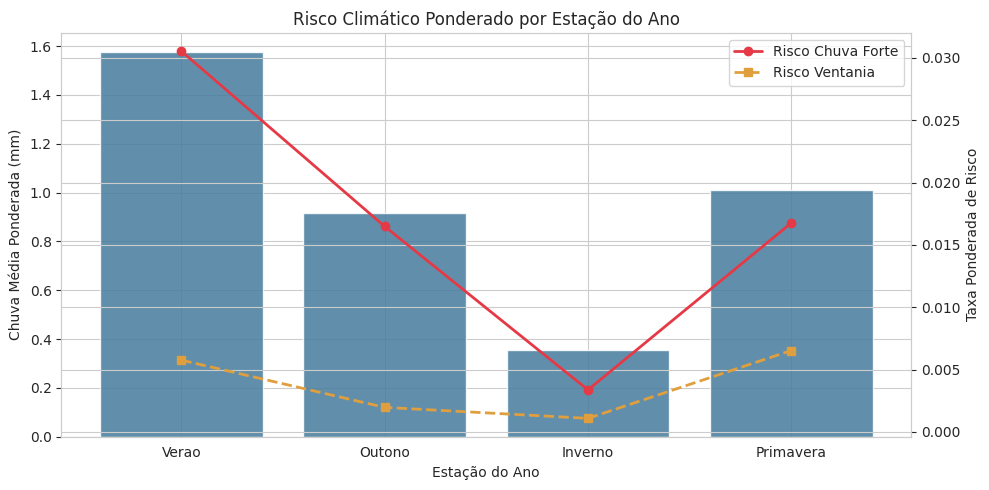

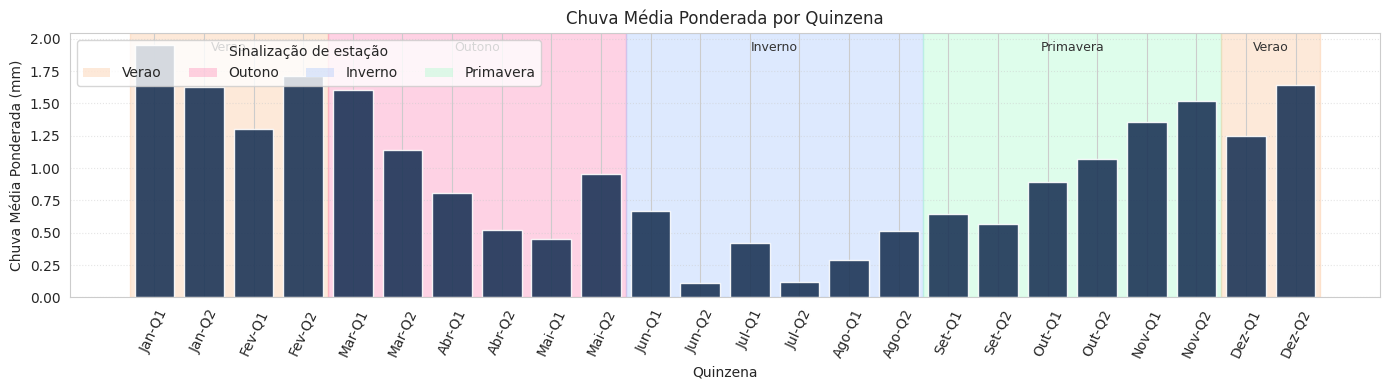


=== CONCLUSÕES PONDERADAS DE RISCO LOGÍSTICO (TODOS OS ANOS) ===
1) Estação mais crítica (taxa de chuvas torrenciais severas) observada na história: Verao (0.0305).
2) Quinzena estatisticamente mais caótica a se focar por incidência de CHUVAS: Jan-Q1 (0.0349).
3) Quinzena estatisticamente mais caótica a se focar por desastres em áreas extremas via VENTANIA: Out-Q2 (0.0111).


In [6]:
# ==========================================
# 7. LAST MILE: ANÁLISE PONDERADA (ANOS, ESTAÇÃO, QUINZENA)
# ==========================================
# Esta célula transforma e resume os dados climáticos já tratados em sinais de risco para
# apoiar visualmente ou tecnicamente as decisões táticas e operacionais de entrega da empresa logística.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Estilo visual padrão da biblioteca seaborn definido p/ simplificar gráficos sem grades poluídas.
sns.set_style("whitegrid")

# ----------------------------------------------------
# 0) PREPARAÇÃO DA BASE
# ----------------------------------------------------
# Converte a base particionada do Spark em formato local em memória via Pandas, pois
# as agregações já reduziram drasticamente os milhões de registros p/ poucos kilobytes, facilitando gráficos nativos PyPlot.
df_en_pd = df_periodo_en.toPandas()

# Separa a data original para extrair facilmente as chaves granulares como ano, mês e dia da coluna datetime.
df_en_pd["date"] = pd.to_datetime(df_en_pd["date"])
df_en_pd["year"] = df_en_pd["date"].dt.year
df_en_pd["month"] = df_en_pd["date"].dt.month
df_en_pd["day"] = df_en_pd["date"].dt.day

# Sinalização binária [0 ou 1] do risco logístico decorrente de temporais na via
# Considera-se risco códigos chuvosos de alerta: 3 (Chuva forte >= 10mm/h) e 4 (Chuva violenta > 50mm/h)
df_en_pd["is_heavy_rain"] = df_en_pd["rain_class_code"].isin([3, 4]).astype(int)

# Sinalização binária do aumento extremo na força do vento, útil para identificar risco em vias de áreas rurais / galhos.
# Código Beaufort 8 em diante indica ventanias de aproximadamente ou superiores a +60km/h (17.2m/s)  e risco logístico.
df_en_pd["is_strong_wind"] = (df_en_pd["wind_class_code"] >= 8).astype(int)

# ----------------------------------------------------
# 1) PESOS POR ANO
# ----------------------------------------------------
# Cria matriz de peso para lidar com a quantidade não perfeitamente linear de dias captados entre
# determinados passados climáticos capturados pelo INMET - dá maior relevância temporal aos anos cujas coletas foram maiores
year_weights = df_en_pd.groupby("year", as_index=False).size().rename(columns={"size": "n"})
year_weights["year_weight"] = year_weights["n"] / year_weights["n"].sum()

# ----------------------------------------------------
# 2) ANÁLISE PONDERADA FOCADA NA ESTAÇÃO DO ANO
# ----------------------------------------------------
# Mapeia categoricamente a macro divisão térmica brasileira
season_map = {
    12: "Verao", 1: "Verao", 2: "Verao",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera"
}
df_en_pd["season"] = df_en_pd["month"].map(season_map)

# Sumariza em agrupamento ano x estação do ano, resultando em: médias históricas de volume total chuvas (mm)
# e incidência das taxas das flags binárias criadas nas etapas logísticas anteriores.
season_year = (
    df_en_pd.groupby(["year", "season"], as_index=False)
           .agg(
               rain_avg_mm=("total_rainfall_period_mm", "mean"),
               heavy_rain_rate=("is_heavy_rain", "mean"),
               strong_wind_rate=("is_strong_wind", "mean")
           )
)

# Cruza os resultados extraidos contra os pesos relativos apurados, trazendo
# o montante correto matematicamente ponderando anos fortes e com maior confiabilidade.
season_weighted = (
    season_year.merge(year_weights[["year", "year_weight"]], on="year", how="left")
               .assign(
                   rain_weighted=lambda d: d["rain_avg_mm"] * d["year_weight"],
                   heavy_weighted=lambda d: d["heavy_rain_rate"] * d["year_weight"],
                   wind_weighted=lambda d: d["strong_wind_rate"] * d["year_weight"]
               )
               .groupby("season", as_index=False)
               .agg(
                   weighted_rain_avg_mm=("rain_weighted", "sum"),
                   weighted_heavy_rain_rate=("heavy_weighted", "sum"),
                   weighted_strong_wind_rate=("wind_weighted", "sum")
               )
)

# Força categoria ordinal (Primavera->Verão->Outono...) para enquadramento correto de gráfico de linhas em vez de a-z clássico PyPlot.
season_order = ["Verao", "Outono", "Inverno", "Primavera"]
season_weighted["season"] = pd.Categorical(season_weighted["season"], categories=season_order, ordered=True)
season_weighted = season_weighted.sort_values("season")

# Plota visualização dupla Eixos X e Y cruzada: Barras demonstram índices estáticos baseados na média acumulada
# e linhas demonstrativas de tendência refletindo probabilidade logística baseada nas classes críticas.
fig, ax1 = plt.subplots(figsize=(10, 5))
# Gráfico de barras indicando a quantidade física milimétrica agregada
ax1.bar(season_weighted["season"], season_weighted["weighted_rain_avg_mm"], color="#457b9d", alpha=0.85, label="Chuva Média Ponderada")
ax1.set_ylabel("Chuva Média Ponderada (mm)")
ax1.set_xlabel("Estação do Ano")

# Duplicação do formato original via twinx para gerar novo plano Cartesiano Y com a outra grandeza de proporção %
ax2 = ax1.twinx()
# Exibição do traçado com Marcadores nos topos assinalando pico temporal
ax2.plot(
    season_weighted["season"],
    season_weighted["weighted_heavy_rain_rate"],
    color="#e63946",
    marker="o",
    linewidth=2,
    label="Risco Chuva Forte"
)
# Linha tracejada ressaltando métricas distintas de Ventania contra Riscos Fluviais
ax2.plot(
    season_weighted["season"],
    season_weighted["weighted_strong_wind_rate"],
    color="#e09f3e",
    marker="s",
    linewidth=2,
    label="Risco Ventania",
    linestyle="--"
)
ax2.set_ylabel("Taxa Ponderada de Risco")

plt.title("Risco Climático Ponderado por Estação do Ano")
ax2.legend(loc="upper right")
fig.tight_layout() # Elimina colisão do texto ao longo das bordas das saídas da célula 
plt.show()

# ----------------------------------------------------
# 3) ANÁLISE POR QUINZENA (1-15, 16-FIM) PONDERADA ENTRE ANOS
# ----------------------------------------------------
# Define quinzena: 1 para dias 1-15 e 2 para dias 16-fim.
df_en_pd["half_month"] = np.where(df_en_pd["day"] <= 15, 1, 2)

# Mapeia nomes numéricos em nomenclaturas textuais padronizadas Pt-BR minimizadas
month_name = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

# Consolida matriz cruzada mês-quinzena. Retorna uma apuração focada de cada trecho específico do calendário natural sobre ano coletado histórico 
fort_year = (
    df_en_pd.groupby(["year", "month", "half_month"], as_index=False)
           .agg(
               rain_avg_mm=("total_rainfall_period_mm", "mean"),
               heavy_rain_rate=("is_heavy_rain", "mean"),
               strong_wind_rate=("is_strong_wind", "mean")
           )
)

# Convolve métricas base com base no dataset extraído, devolvendo o vetor exato de peso para mitigar amostragens não padronizadas p/ ano
fort_weighted = (
    fort_year.merge(year_weights[["year", "year_weight"]], on="year", how="left")
             .assign(
                 rain_weighted=lambda d: d["rain_avg_mm"] * d["year_weight"],
                 heavy_weighted=lambda d: d["heavy_rain_rate"] * d["year_weight"],
                 wind_weighted=lambda d: d["strong_wind_rate"] * d["year_weight"]
             )
             .groupby(["month", "half_month"], as_index=False)
             .agg(
                 weighted_rain_avg_mm=("rain_weighted", "sum"),
                 weighted_heavy_rain_rate=("heavy_weighted", "sum"),
                 weighted_strong_wind_rate=("wind_weighted", "sum")
             )
)

# Mescla a variável quinzena + label formatado extraido acima "Mês X - Q 1" vs "Mês X - Q 2" ex: "Fev-Q1"
fort_weighted["fortnight_label"] = fort_weighted.apply(
    lambda r: f"{month_name[int(r['month'])]}-Q{int(r['half_month'])}", axis=1
)

# Extrai e estabelece a ordem numérica cronológica progressiva que deve ir de começo do ano jan até fim e repassado o "ord" no pandas dataframe. 
fort_weighted["ord"] = (fort_weighted["month"] - 1) * 2 + fort_weighted["half_month"]
fort_weighted = fort_weighted.sort_values("ord")


# ----------------------------------------------------
# 4) GRÁFICO: CHUVA PONDERADA VS TEMPORALIDADE ESTAÇÃO (24 quinzenas Totais no ano)
# ----------------------------------------------------
# Dicionário inverso base atrelando os 12 meses nas quatro grandes definições das estações naturais
month_to_season = {
    1: "Verao", 2: "Verao", 3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno", 9: "Primavera",
    10: "Primavera", 11: "Primavera", 12: "Verao"
}
fort_weighted["season"] = fort_weighted["month"].map(month_to_season)

# Esquema de cores representativas e intuitivas utilizadas de pano de fundo na janela axvspan para cada época correspondente (Inverno Azul, Outono Rosa/Laranja, Etc.)
season_bg_colors = {
    "Verao": "#fcc092",
    "Outono": "#fe7fb2",
    "Inverno": "#a0c2fe",
    "Primavera": "#a1fcc8"
}

# Redefine chaves pandas após limpeza de índice.
fort_weighted = fort_weighted.reset_index(drop=True)

# Percorre quinzenalmente iterativa os rótulos de cada pedaço gráfico e calcula onde deve iniciar um fundo delimitado colorido
season_spans = []
start_idx = 0
for i in range(1, len(fort_weighted)):
    if fort_weighted.loc[i, "season"] != fort_weighted.loc[i - 1, "season"]:
        season_spans.append((fort_weighted.loc[i - 1, "season"], start_idx, i - 1))
        start_idx = i
season_spans.append((fort_weighted.loc[len(fort_weighted) - 1, "season"], start_idx, len(fort_weighted) - 1))

# Construção complexa do ploteamento das 24 quinzenas em modelo horizontal e contínuo temporal para apoiar as decisões diárias
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(fort_weighted["fortnight_label"], fort_weighted["weighted_rain_avg_mm"], color="#1d3557", alpha=0.9)

for season, i_start, i_end in season_spans:
    ax.axvspan(i_start - 0.5, i_end + 0.5, color=season_bg_colors[season], alpha=0.35, zorder=0)
    mid = (i_start + i_end) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.97, season, ha="center", va="top", fontsize=9, color="#333333")

ax.set_title("Chuva Média Ponderada por Quinzena")
ax.set_xlabel("Quinzena")
ax.set_ylabel("Chuva Média Ponderada (mm)")
ax.set_xticks(range(len(fort_weighted)))
ax.set_xticklabels(fort_weighted["fortnight_label"], rotation=65)
ax.grid(axis="y", linestyle=":", alpha=0.5)

legend_handles = [Patch(facecolor=season_bg_colors[s], edgecolor="none", alpha=0.35, label=s) for s in ["Verao", "Outono", "Inverno", "Primavera"]]
ax.legend(handles=legend_handles, title="Sinalização de estação", ncol=4, loc="upper left")

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 5) EXTRAÇÃO DE CONCLUSÕES E INSIGHTS DE NEGÓCIO
# ----------------------------------------------------
# Ordena do maior risco climático obtido c/ base histórica ao menor e armazena na variável indicando o Top 1 mais problemático p/ transportes 
worst_season_rain = season_weighted.sort_values("weighted_heavy_rain_rate", ascending=False).iloc[0]
worst_fort_rain = fort_weighted.sort_values("weighted_heavy_rain_rate", ascending=False).iloc[0]
worst_fort_wind = fort_weighted.sort_values("weighted_strong_wind_rate", ascending=False).iloc[0]

# Informa via Console explicitamente em strings de alerta final, a quem visualizar o processamento deste Pipeline ETL e Machine Learning Logístico.
print("\n=== CONCLUSÕES PONDERADAS DE RISCO LOGÍSTICO (TODOS OS ANOS) ===")
print(f"1) Estação mais crítica (taxa de chuvas torrenciais severas) observada na história: {worst_season_rain['season']} ({worst_season_rain['weighted_heavy_rain_rate']:.4f}).")
print(f"2) Quinzena estatisticamente mais caótica a se focar por incidência de CHUVAS: {worst_fort_rain['fortnight_label']} ({worst_fort_rain['weighted_heavy_rain_rate']:.4f}).")
print(f"3) Quinzena estatisticamente mais caótica a se focar por desastres em áreas extremas via VENTANIA: {worst_fort_wind['fortnight_label']} ({worst_fort_wind['weighted_strong_wind_rate']:.4f}).")

# weather_risk_calendar = fort_weighted[["month", "half_month", "weighted_rain_avg_mm", "weighted_heavy_rain_rate", "weighted_strong_wind_rate"]].copy()
# print("\nBase enxuta sugerida para regra de negócio (Calendário de Risco):")
# print(weather_risk_calendar.head(10))


In [7]:
df_periodo_en.coalesce(1) \
        .write \
        .option('header', 'true') \
        .mode('overwrite') \
        .csv('s3a://last-mile-optimization-trusted-otavio/clean_weather_data.csv')

26/04/18 02:44:43 WARN AbstractS3ACommitterFactory: Using standard FileOutputCommitter to commit work. This is slow and potentially unsafe.
26/04/18 02:44:43 WARN AbstractS3ACommitterFactory: Using standard FileOutputCommitter to commit work. This is slow and potentially unsafe.
